# Phase III: Envelope optimization integrated into surroundings

**Building:** Linear Building · **Model:** `models/linear_envelope_wwr25.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_envelope_wwr25_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/linear_envelope_wwr25.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 7:19:06.388162


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147945,0.083199,0.145923,0.063597,0.131944,0.775860,0.656119,0.008300,24.000129,2.172925e+11,1.905178e+09,0,True
1,0.001679,0.098022,0.000605,0.022676,0.003741,0.256716,0.201142,0.005054,19.176631,7.897133e+10,2.343336e+11,0,True
2,0.036803,0.038539,0.007286,0.018215,0.004258,0.204484,0.200685,0.005275,19.631489,7.967265e+10,1.771320e+11,0,True
3,0.006722,0.093097,0.028852,0.067505,0.108985,0.240540,0.313343,0.004944,21.147068,8.216889e+10,5.415973e+10,0,True
4,0.145821,0.068358,0.142587,0.072949,0.149340,0.717042,0.510549,0.009869,22.991419,1.568010e+11,2.100458e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000511,0.134832,0.031314,0.072246,0.110651,0.303425,0.268637,0.004023,22.090187,9.004306e+10,5.478223e+10,0,False
96,0.058890,0.018351,0.018877,0.013680,0.031865,0.201071,0.202654,0.003270,19.493823,8.461327e+10,1.518715e+11,0,False
97,0.112034,0.147718,0.057904,0.114846,0.145950,0.310276,0.264167,0.003735,21.684194,9.899866e+10,1.185516e+10,0,False
98,0.121514,0.106383,0.135501,0.082414,0.136450,0.456403,0.752564,0.007806,22.842504,1.382364e+11,3.138257e+09,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147945,0.083199,0.145923,0.063597,0.131944,0.775860,0.656119,0.008300,24.000129,68.891219,0.604024,0,True
1,0.001679,0.098022,0.000605,0.022676,0.003741,0.256716,0.201142,0.005054,19.176631,25.037358,74.293965,0,True
2,0.036803,0.038539,0.007286,0.018215,0.004258,0.204484,0.200685,0.005275,19.631489,25.259705,56.158564,0,True
3,0.006722,0.093097,0.028852,0.067505,0.108985,0.240540,0.313343,0.004944,21.147068,26.051123,17.170999,0,True
4,0.145821,0.068358,0.142587,0.072949,0.149340,0.717042,0.510549,0.009869,22.991419,49.712749,0.665937,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000511,0.134832,0.031314,0.072246,0.110651,0.303425,0.268637,0.004023,22.090187,28.547578,17.368356,0,False
96,0.058890,0.018351,0.018877,0.013680,0.031865,0.201071,0.202654,0.003270,19.493823,26.826098,48.149893,0,False
97,0.112034,0.147718,0.057904,0.114846,0.145950,0.310276,0.264167,0.003735,21.684194,31.386894,3.758604,0,False
98,0.121514,0.106383,0.135501,0.082414,0.136450,0.456403,0.752564,0.007806,22.842504,43.826976,0.994964,0,False


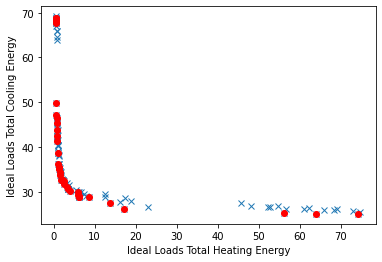

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_envelope_wwr25_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

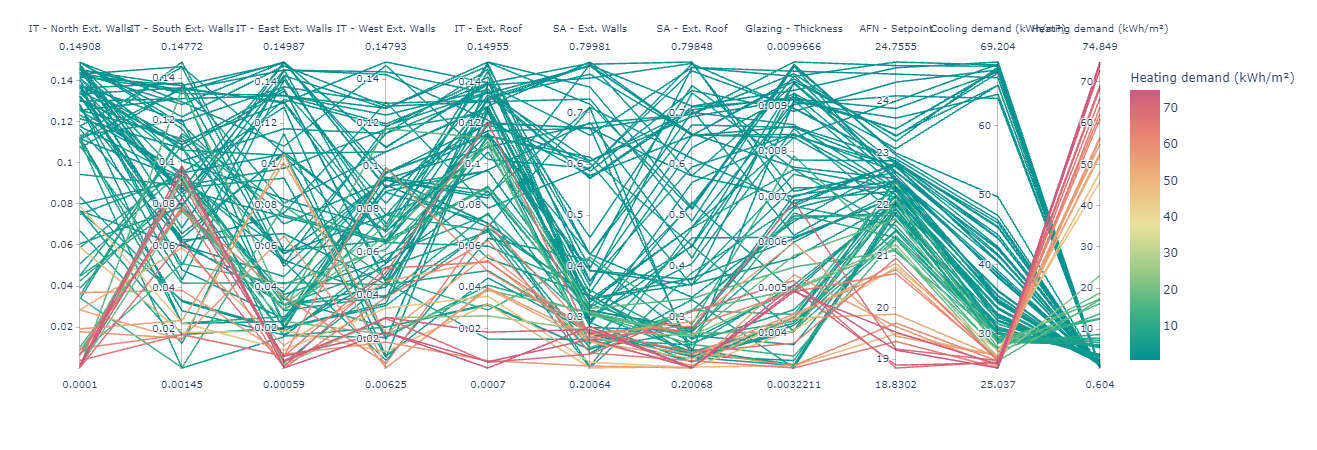

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147945,0.083199,0.145923,0.063597,0.131944,0.775860,0.656119,0.008300,24.000129,68.891219,0.604024,0,True
1,0.001679,0.098022,0.000605,0.022676,0.003741,0.256716,0.201142,0.005054,19.176631,25.037358,74.293965,0,True
2,0.036803,0.038539,0.007286,0.018215,0.004258,0.204484,0.200685,0.005275,19.631489,25.259705,56.158564,0,True
3,0.006722,0.093097,0.028852,0.067505,0.108985,0.240540,0.313343,0.004944,21.147068,26.051123,17.170999,0,True
4,0.145821,0.068358,0.142587,0.072949,0.149340,0.717042,0.510549,0.009869,22.991419,49.712749,0.665937,0,True
5,0.143439,0.134399,0.145897,0.142114,0.121270,0.577537,0.654566,0.009593,23.316981,67.630476,0.661587,0,True
6,0.006361,0.078541,0.000586,0.039008,0.062765,0.230102,0.214793,0.003221,19.344706,25.074102,63.897626,0,True
7,0.010374,0.076515,0.028852,0.064295,0.088385,0.307369,0.246605,0.003484,21.324983,27.425421,13.761684,0,True
8,0.044789,0.080319,0.016316,0.020446,0.040999,0.307689,0.259685,0.006633,21.351781,28.714272,8.733170,0,True
9,0.148681,0.121527,0.147996,0.127428,0.130250,0.727187,0.487627,0.009872,22.443947,38.729221,0.996466,0,True


In [11]:
results.to_csv('../results/linear_envelope_wwr25_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
27,0.066869,0.013157,0.114999,0.011791,0.044499,0.270002,0.222738,0.004315,22.174936,30.601344,3.428143,0,True
